# Fine-tune rubert-tiny2 — детектор персональных данных

Обучает модель-детектор для задачи хакатона из `Hackathon task.md`: находит спаны 24 типов ПД.
Публичные персоны и адреса отделений банков — не ПД, в данных это чистые негативы (без спанов).
Маскирование и демаскирование — детерминированная логика сервиса поверх детектора,
в notebook не входят.

**Подход:** BIO-теггер поверх `cointegrated/rubert-tiny2` (3 слоя, hidden 312, vocab 83 828,
max_pos 2048). Выход модели: список `(start, end, label)` — символьные оффсеты в исходном тексте.

## План

1. Setup, конфиг, загрузка CSV из `data/csv/`
2. EDA: длины, распределения меток
3. BIO-теггинг с приоритетами: `BIRTH_PLACE` > близнецов `CITY/COUNTRY`, innermost-wins (`CITY/STREET/HOUSE` вместо контейнера `ADDRESS`)
4. Датасет: токенизация с overflow (max_len 1024, stride 128), class weights
5. Инференс: чанки → голосование по токенам → BIO-декод → char-спаны
6. Метрики детекции: span-F1 (micro/macro/per-label), char-coverage P/R/F1
7. Обучение: AdamW lr=3e-4, warmup 10% + cosine, bs=32, до 10 эпох, лучший чекпоинт по dev macro span-F1
8. Валидация на test + анализ ошибок
9. Артефакты: `model_piinet/` + ONNX int8 для CPU-сервиса

## Как запускать

- Ядро Python 3 с GPU (CUDA или MPS), ячейки сверху вниз.
- Полный прогон: ~30–60 мин обучение + ~5 мин инференс и метрики.
- Данные: `data/csv/{train,dev,test}.csv` (переопределяется env `PII_DATA_DIR`), вывод в `model_piinet/` (env `PII_OUT_DIR`).

## Метрики

- Качество модели = качество детекции: span-F1 (точное совпадение тройки start/end/label) и
  char-coverage (какие символы попадут под маскирование).
- Итоговая метрика ТЗ (нормированный Левенштейн между масками) вычисляется на уровне сервиса
  после подключения правил маскирования: от модели зависит только детекция.

## Setup

In [1]:
import json
import math
import os
import random
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import transformers
from transformers import AutoModelForTokenClassification, AutoTokenizer

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"torch={torch.__version__} transformers={transformers.__version__} device={DEVICE}")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch=2.9.1+cu128 transformers=5.14.1 device=cuda


## Конфигурация

In [3]:
def find_data_dir():
    env = os.environ.get("PII_DATA_DIR")
    if env:
        return Path(env)
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("data/csv", "csv"):
            if (cand / sub / "train.csv").exists():
                return cand / sub
    return Path.cwd() / "data" / "csv"

DATA_DIR = find_data_dir()
OUT_DIR = Path(os.environ.get("PII_OUT_DIR", str(DATA_DIR.parent / "model_piinet")))
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = os.environ.get("PII_MODEL_NAME", "models/rubert-tiny2")
MAX_LEN = 1024
STRIDE = 128

PII_LABELS = [
    "APARTMENT", "BIRTH_DATE", "BIRTH_PLACE", "CARDHOLDER", "CARD_NUMBER",
    "CITIZENSHIP", "CITY", "COUNTRY", "CVV", "DRIVER_LICENSE_NUMBER",
    "DRIVER_LICENSE_SERIES", "EMAIL", "HOUSE", "INN", "PASSPORT_DIVISION_CODE",
    "PASSPORT_ISSUER", "PASSPORT_ISSUE_DATE", "PASSPORT_NUMBER", "PASSPORT_SERIES",
    "PERSON", "PHONE", "PIN", "POSTAL_CODE", "STREET",
]
LABELS = PII_LABELS

TAGS = ["O"] + [f"{p}-{lab}" for lab in LABELS for p in ("B", "I")]
TAG2ID = {t: i for i, t in enumerate(TAGS)}
ID2TAG = {i: t for t, i in TAG2ID.items()}
N_CLASSES = len(TAGS)

HP = {
    "lr": 3e-4,
    "epochs": 10,
    "patience": 3,
    "batch_size": 128,
    "eval_batch_size": 256,
    "weight_decay": 0.01,
    "warmup_frac": 0.1,
    "grad_clip": 1.0,
    "weight_cap": 10.0,
}

EXPECTED_COUNTS = {"train": 91713, "dev": 10961, "test": 11044}

assert DATA_DIR.is_dir(), f"data dir not found: {DATA_DIR}"
print(f"{len(LABELS)} labels, {N_CLASSES} BIO classes")
print(f"data={DATA_DIR} | out={OUT_DIR}")
print(f"HP={HP}")

24 labels, 49 BIO classes
data=/workspace/models/alfa_hack/data/csv | out=/workspace/models/alfa_hack/data/model_piinet
HP={'lr': 0.0003, 'epochs': 10, 'patience': 3, 'batch_size': 128, 'eval_batch_size': 256, 'weight_decay': 0.01, 'warmup_frac': 0.1, 'grad_clip': 1.0, 'weight_cap': 10.0}


## Данные

In [4]:
def load_split(name):
    df = pd.read_csv(DATA_DIR / f"{name}.csv")
    rows = [
        {"id": r.id, "source": r.source, "text": r.text, "entities": json.loads(r.entities)}
        for r in df.itertuples(index=False)
    ]
    assert len(rows) == EXPECTED_COUNTS[name], f"{name}: {len(rows)} != {EXPECTED_COUNTS[name]}"
    return rows

train_rows = load_split("train")
dev_rows = load_split("dev")
test_rows = load_split("test")

for name, rows in (("train", train_rows), ("dev", dev_rows), ("test", test_rows)):
    n_ent = sum(len(r["entities"]) for r in rows)
    print(f"{name}: {len(rows)} texts, {n_ent} entities")

for name, rows in (("train", train_rows), ("dev", dev_rows), ("test", test_rows)):
    for r in random.sample(rows, min(200, len(rows))):
        for e in r["entities"]:
            assert r["text"][e["start"]:e["end"]] == e["text"], (name, r["id"], e)
print("offset sanity: OK")

train: 91713 texts, 240707 entities
dev: 10961 texts, 28724 entities
test: 11044 texts, 29075 entities
offset sanity: OK


## EDA

BertTokenizer vocab: 83828 model_max_length: 2048
         train      dev     test
count  91713.0  10961.0  11044.0
mean     151.9    151.8    154.5
std      174.4    151.7    183.2
min        1.0      5.0      3.0
50%      132.0    132.0    133.0
90%      204.0    202.0    206.0
99%      607.0    413.2    440.4
max    12932.0   3756.0  10240.0
train tokens (sample 2000): {'count': 2000.0, 'mean': 48.3, 'std': 47.6, 'min': 3.0, '50%': 39.0, '90%': 87.0, '99%': 272.0, 'max': 501.0}
PERSON                    51920
CITY                      19630
PHONE                     19047
EMAIL                     18103
STREET                    13904
HOUSE                     12712
INN                       11482
PASSPORT_NUMBER           10109
PASSPORT_SERIES           10109
BIRTH_DATE                10085
CARD_NUMBER                9067
COUNTRY                    7796
DRIVER_LICENSE_SERIES      7577
DRIVER_LICENSE_NUMBER      7577
POSTAL_CODE                7487
ADDRESS                    3273
PA

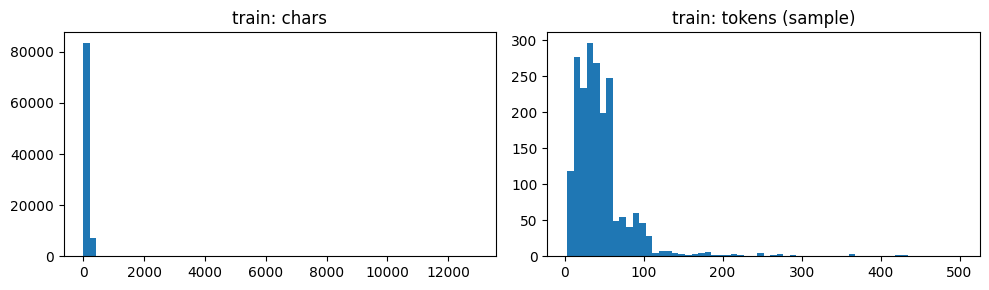

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(type(tokenizer).__name__, "vocab:", tokenizer.vocab_size, "model_max_length:", tokenizer.model_max_length)
assert MAX_LEN <= tokenizer.model_max_length

length_stats = {}
for name, rows in (("train", train_rows), ("dev", dev_rows), ("test", test_rows)):
    length_stats[name] = pd.Series([len(r["text"]) for r in rows]).describe(percentiles=[0.5, 0.9, 0.99])
print(pd.DataFrame(length_stats).round(1))

sample_enc = tokenizer([r["text"] for r in train_rows[:2000]])
sample_tokens = pd.Series([len(x) for x in sample_enc["input_ids"]])
print("train tokens (sample 2000):", sample_tokens.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_dict())

lab_counts = Counter(e["label"] for r in train_rows for e in r["entities"])
print(pd.Series(lab_counts).sort_values(ascending=False).to_string())

src_counts = Counter(r["source"] for r in train_rows)
print(pd.Series(src_counts).to_string())

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist([len(r["text"]) for r in train_rows], bins=60)
    axes[0].set_title("train: chars")
    axes[1].hist(sample_tokens, bins=60)
    axes[1].set_title("train: tokens (sample)")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("plot skipped:", exc)

## BIO-теггинг

Приоритет метки на токен при вложенности: `BIRTH_PLACE` (близнецы с `CITY/COUNTRY`)
→ innermost-wins (`CITY/STREET/HOUSE` вместо контейнера `ADDRESS`).
Контейнер `ADDRESS` в данных всегда полностью выводится из своих частей.

In [6]:
PRIORITY = {"BIRTH_PLACE": 1}


def span_priority(ent):
    return (PRIORITY.get(ent["label"], 2), ent["end"] - ent["start"], ent["start"], ent["label"])


def token_labels_from_entities(entities, offsets):
    ents = [e for e in entities if e["label"] != "ADDRESS"]
    labels = []
    for s, e in offsets:
        if s == e:
            labels.append(-100)
            continue
        covering = [x for x in ents if x["start"] < e and x["end"] > s]
        if not covering:
            labels.append(0)
            continue
        best = min(covering, key=span_priority)
        prefix = "B" if s == best["start"] else "I"
        labels.append(TAG2ID[f"{prefix}-{best['label']}"])
    return labels


def bio_decode(offsets, tag_ids):
    spans = []
    cur = None
    for (s, e), tid in zip(offsets, tag_ids):
        tag = ID2TAG[tid]
        if tag == "O":
            if cur is not None:
                spans.append(cur)
                cur = None
            continue
        prefix, label = tag.split("-", 1)
        if prefix == "B" or cur is None or cur[2] != label:
            if cur is not None:
                spans.append(cur)
            cur = (s, e, label)
        else:
            cur = (cur[0], e, cur[2])
    if cur is not None:
        spans.append(cur)
    return spans


def canonical_gold_spans(text, entities):
    enc = tokenizer(text, return_offsets_mapping=True, add_special_tokens=False, truncation=False)
    labels = token_labels_from_entities(entities, enc["offset_mapping"])
    return bio_decode(enc["offset_mapping"], labels)


def show_canonical(rows, wanted):
    for r in rows:
        if wanted in {e["label"] for e in r["entities"]}:
            print("TEXT :", r["text"][:200])
            print("RAW  :", [(e["label"], r["text"][e["start"]:e["end"]]) for e in r["entities"]])
            print("CANON:", [(lab, r["text"][s:e]) for s, e, lab in canonical_gold_spans(r["text"], r["entities"])])
            print()
            return
    print(f"no rows with {wanted}")


show_canonical(train_rows, "ADDRESS")
show_canonical(train_rows, "BIRTH_PLACE")

TEXT : АДРЕС РЕГИСТРАЦИИ КЛИЕНТА: ПСКОВ, СОСНОВАЯ 25; СТРАНА: РФ; ИНДЕКС: 617903; РЕГИОН: ПЕРМСКИЙ КРАЙ; АДРЕС: КАЗАНЬ, ПОЛЕВАЯ 75; КОРПУС: 1; КВАРТИРА: 44; 
УЧЕБНЫЙ ИДЕНТИФИКАТОР TRAIN-009265.
RAW  : [('ADDRESS', 'ПСКОВ, СОСНОВАЯ 25'), ('CITY', 'ПСКОВ'), ('STREET', 'СОСНОВАЯ'), ('HOUSE', '25'), ('COUNTRY', 'РФ'), ('POSTAL_CODE', '617903'), ('ADDRESS', 'КАЗАНЬ, ПОЛЕВАЯ 75'), ('CITY', 'КАЗАНЬ'), ('STREET', 'ПОЛЕВАЯ'), ('HOUSE', '75'), ('APARTMENT', '44')]
CANON: [('CITY', 'ПСКОВ'), ('STREET', 'СОСНОВАЯ'), ('HOUSE', '25'), ('COUNTRY', 'РФ'), ('POSTAL_CODE', '617903'), ('CITY', 'КАЗАНЬ'), ('STREET', 'ПОЛЕВАЯ'), ('HOUSE', '75'), ('APARTMENT', '44')]

TEXT : АНКЕТА КЛИЕНТА. ФИО: ЗАХАРОВ МАКСИМ ОЛЕГОВИЧ; ДАТА РОЖДЕНИЯ: 1968.27.04; МЕСТО РОЖДЕНИЯ: ОМСК; ГРАЖДАНСТВО: КАЗАХСТАН; 
УЧЕБНЫЙ ИДЕНТИФИКАТОР TRAIN-001672.
RAW  : [('PERSON', 'ЗАХАРОВ МАКСИМ ОЛЕГОВИЧ'), ('BIRTH_DATE', '1968.27.04'), ('BIRTH_PLACE', 'ОМСК'), ('CITIZENSHIP', 'КАЗАХСТАН')]
CANON: [('PERSON', 'ЗАХАРОВ МАКСИМ ОЛЕГОВИЧ'), ('B

## Маскируемые спаны

    Отображение детекции → то, что попадёт под маскирование в сервисе:
    все детектированные спаны (публичные персоны и адреса отделений — не ПД,
    в разметке отсутствуют, модель должна их пропускать).

In [7]:
def maskable_spans(spans):
    spans = sorted(spans, key=lambda x: (x[0], x[1]))
    out = []
    for s, e, lab in spans:
        if out and s < out[-1][1]:
            continue
        out.append((s, e, lab))
    return out


shown = 0
for r in train_rows:
    gold = canonical_gold_spans(r["text"], r["entities"])
    if gold and shown < 3:
        shown += 1
        print("TEXT    :", r["text"][:200])
        print("DETECTED:", [(r["text"][s:e], lab) for s, e, lab in gold])
        print("MASKABLE:", [(r["text"][s:e], lab) for s, e, lab in maskable_spans(gold)])

TEXT    : Ранее И.Клебанов работал в российском правительстве : на посту вице-премьера он курировал военно-промышленный комплекс .
DETECTED: [('И.Клебанов', 'PERSON')]
MASKABLE: [('И.Клебанов', 'PERSON')]
TEXT    : КОНТАКТЫ КЛИЕНТА СОКОЛОВ МАКСИМ АНДРЕЕВИЧ: ТЕЛЕФОН: +71392433825; EMAIL: CLIENT6868.TRAIN@EXAMPLE.ORG; ИНН ФИЗЛИЦА: 287798352265; 
УЧЕБНЫЙ ИДЕНТИФИКАТОР TRAIN-006868.
DETECTED: [('СОКОЛОВ МАКСИМ АНДРЕЕВИЧ', 'PERSON'), ('+71392433825', 'PHONE'), ('CLIENT6868.TRAIN@EXAMPLE.ORG', 'EMAIL'), ('287798352265', 'INN')]
MASKABLE: [('СОКОЛОВ МАКСИМ АНДРЕЕВИЧ', 'PERSON'), ('+71392433825', 'PHONE'), ('CLIENT6868.TRAIN@EXAMPLE.ORG', 'EMAIL'), ('287798352265', 'INN')]
TEXT    : для идентификации клиента соколов андрей николаевич нужны реквизиты. документ: паспорт рф, серия 68 07, номер: 435349; кем выдан: умвд россии по тульской области; код подразделения: 934 185; дата выда
DETECTED: [('соколов андрей николаевич', 'PERSON'), ('68 07', 'PASSPORT_SERIES'), ('435349', 'PASSPORT_NUMBER'), ('

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2392 > 2048). Running this sequence through the model will result in indexing errors


## Датасет и class weights

In [8]:
def build_samples(rows):
    enc = tokenizer(
        [r["text"] for r in rows],
        return_offsets_mapping=True,
        truncation=True,
        max_length=MAX_LEN,
        stride=STRIDE,
        return_overflowing_tokens=True,
    )
    owner = enc["overflow_to_sample_mapping"]
    samples = []
    for i in range(len(enc["input_ids"])):
        row = rows[owner[i]]
        samples.append({
            "input_ids": enc["input_ids"][i],
            "labels": token_labels_from_entities(row["entities"], enc["offset_mapping"][i]),
            "n_tokens": len(enc["input_ids"][i]),
        })
    return samples


t0 = time.time()
train_samples = build_samples(train_rows)
dev_samples = build_samples(dev_rows)
test_samples = build_samples(test_rows)
print(f"chunks: train={len(train_samples)} dev={len(dev_samples)} test={len(test_samples)} ({time.time() - t0:.1f}s)")

tag_counts = Counter()
for smp in train_samples:
    tag_counts.update(t for t in smp["labels"] if t != -100)
counts = np.zeros(N_CLASSES)
for tag_id, c in tag_counts.items():
    counts[tag_id] = c
non_o = counts[1:]
ref = float(np.median(non_o[non_o > 0]))
weights = np.ones(N_CLASSES)
for i in range(1, N_CLASSES):
    if counts[i] > 0:
        weights[i] = min(HP["weight_cap"], max(1.0, (ref / counts[i]) ** 0.5))
class_weights = torch.tensor(weights, dtype=torch.float32)

weight_table = pd.DataFrame({
    "tag": [ID2TAG[i] for i in range(N_CLASSES)],
    "count": counts.astype(int),
    "weight": weights.round(2),
})
print(weight_table[weight_table["count"] > 0].to_string(index=False))

chunks: train=91723 dev=10961 test=11046 (7.2s)
                     tag   count  weight
                       O 2606723    1.00
             B-APARTMENT    2182    2.15
            B-BIRTH_DATE   10085    1.00
            I-BIRTH_DATE   39197    1.00
           B-BIRTH_PLACE    2286    2.10
           I-BIRTH_PLACE    2498    2.01
            B-CARDHOLDER    1091    3.04
            I-CARDHOLDER    6024    1.29
           B-CARD_NUMBER    8215    1.11
           I-CARD_NUMBER   73696    1.00
           B-CITIZENSHIP    2182    2.15
           I-CITIZENSHIP    2903    1.86
                  B-CITY   19558    1.00
                  I-CITY   53685    1.00
               B-COUNTRY    7795    1.14
               I-COUNTRY    4064    1.57
                   B-CVV    2181    2.15
                   I-CVV      88   10.00
 B-DRIVER_LICENSE_NUMBER    7577    1.15
 I-DRIVER_LICENSE_NUMBER   15606    1.00
 B-DRIVER_LICENSE_SERIES    7117    1.19
 I-DRIVER_LICENSE_SERIES    8330    1.10
         

## Инференс

In [9]:
def collate(samples):
    n = max(len(s["input_ids"]) for s in samples)
    input_ids, attention_mask, labels = [], [], []
    for s in samples:
        ids = s["input_ids"]
        pad = n - len(ids)
        input_ids.append(list(ids) + [tokenizer.pad_token_id] * pad)
        attention_mask.append([1] * len(ids) + [0] * pad)
        lab = s.get("labels")
        if lab is None:
            labels.append([-100] * n)
        else:
            labels.append(list(lab) + [-100] * pad)
    return (
        torch.tensor(input_ids, dtype=torch.long),
        torch.tensor(attention_mask, dtype=torch.long),
        torch.tensor(labels, dtype=torch.long),
    )


@torch.no_grad()
def predict_texts(model, texts, batch_size=None):
    was_training = model.training
    model.eval()
    bs = batch_size or HP["eval_batch_size"]
    enc = tokenizer(
        texts,
        return_offsets_mapping=True,
        truncation=True,
        max_length=MAX_LEN,
        stride=STRIDE,
        return_overflowing_tokens=True,
    )
    owner = enc["overflow_to_sample_mapping"]
    votes = [dict() for _ in texts]
    order = sorted(range(len(enc["input_ids"])), key=lambda i: len(enc["input_ids"][i]))
    for i in range(0, len(order), bs):
        idxs = order[i:i + bs]
        input_ids, attention_mask, _ = collate([{"input_ids": enc["input_ids"][j]} for j in idxs])
        logits = model(input_ids=input_ids.to(DEVICE), attention_mask=attention_mask.to(DEVICE)).logits
        probs = torch.softmax(logits, dim=-1)
        conf, pred = probs.max(dim=-1)
        for bi, j in enumerate(idxs):
            text_idx = owner[j]
            for k, (s, e) in enumerate(enc["offset_mapping"][j]):
                if s == e:
                    continue
                key = (s, e)
                p = float(conf[bi, k])
                cur = votes[text_idx].get(key)
                if cur is None or p > cur[1]:
                    votes[text_idx][key] = (int(pred[bi, k]), p)
    if was_training:
        model.train()
    return [bio_decode(sorted(v), [v[k][0] for k in sorted(v)]) for v in votes]

## Метрики детекции

In [10]:
def span_prf(gold_lists, pred_lists):
    tp, fp, fn = Counter(), Counter(), Counter()
    for gold, pred in zip(gold_lists, pred_lists):
        gs, ps = set(gold), set(pred)
        for sp in ps:
            if sp in gs:
                tp[sp[2]] += 1
            else:
                fp[sp[2]] += 1
        for sg in gs:
            if sg not in ps:
                fn[sg[2]] += 1
    rows = []
    for lab in sorted(set(tp) | set(fp) | set(fn)):
        p = tp[lab] / (tp[lab] + fp[lab]) if tp[lab] + fp[lab] else 0.0
        r = tp[lab] / (tp[lab] + fn[lab]) if tp[lab] + fn[lab] else 0.0
        f = 2 * p * r / (p + r) if p + r else 0.0
        rows.append((lab, tp[lab], fp[lab], fn[lab], p, r, f))
    df = pd.DataFrame(rows, columns=["label", "tp", "fp", "fn", "precision", "recall", "f1"]).sort_values("f1")
    TP, FP, FN = sum(tp.values()), sum(fp.values()), sum(fn.values())
    micro_p = TP / (TP + FP) if TP + FP else 0.0
    micro_r = TP / (TP + FN) if TP + FN else 0.0
    micro_f = 2 * micro_p * micro_r / (micro_p + micro_r) if micro_p + micro_r else 0.0
    present = [row for row in rows if row[1] + row[3] > 0]
    macro_f = float(np.mean([row[6] for row in present])) if present else 0.0
    return micro_f, macro_f, df


def _char_positions(spans):
    pos = set()
    for s, e, _ in maskable_spans(spans):
        pos.update(range(s, e))
    return pos


def coverage_stats(gold_lists, pred_lists):
    inter = union_gold = union_pred = 0
    for gold, pred in zip(gold_lists, pred_lists):
        gp = _char_positions(gold)
        pp = _char_positions(pred)
        inter += len(gp & pp)
        union_gold += len(gp)
        union_pred += len(pp)
    p = inter / union_pred if union_pred else 1.0
    r = inter / union_gold if union_gold else 1.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f


def text_char_f1(gold, pred):
    gp = _char_positions(gold)
    pp = _char_positions(pred)
    if not gp and not pp:
        return 1.0
    inter = len(gp & pp)
    p = inter / len(pp) if pp else 1.0
    r = inter / len(gp) if gp else 1.0
    return 2 * p * r / (p + r) if p + r else 0.0

## Обучение

In [11]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_CLASSES,
    id2label={i: t for t, i in TAG2ID.items()},
    label2id=TAG2ID,
)
model.to(DEVICE)


def epoch_batches(samples, batch_size, rng):
    order = sorted(range(len(samples)), key=lambda i: samples[i]["n_tokens"] + rng.random() * 3)
    batches = [order[i:i + batch_size] for i in range(0, len(order), batch_size)]
    rng.shuffle(batches)
    return batches


train_gen = random.Random(SEED)
steps_per_epoch = math.ceil(len(train_samples) / HP["batch_size"])
total_steps = steps_per_epoch * HP["epochs"]
warmup_steps = int(HP["warmup_frac"] * total_steps)
optimizer = torch.optim.AdamW(model.parameters(), lr=HP["lr"], weight_decay=HP["weight_decay"])


def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), ignore_index=-100)


@torch.no_grad()
def eval_loss(model, samples, batch_size=None):
    was_training = model.training
    model.eval()
    bs = batch_size or HP["eval_batch_size"]
    order = sorted(range(len(samples)), key=lambda i: samples[i]["n_tokens"])
    losses = []
    for i in range(0, len(order), bs):
        batch = collate([samples[j] for j in order[i:i + bs]])
        input_ids, attention_mask, labels = (t.to(DEVICE) for t in batch)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        losses.append(loss_fn(logits.reshape(-1, N_CLASSES), labels.reshape(-1)).item())
    if was_training:
        model.train()
    return float(np.mean(losses))

dev_texts = [r["text"] for r in dev_rows]
gold_dev = [canonical_gold_spans(r["text"], r["entities"]) for r in dev_rows]

history = []
best_val_loss = float("inf")
best_epoch = 0
t_start = time.time()

for epoch in range(1, HP["epochs"] + 1):
    model.train()
    t0 = time.time()
    losses = []
    epoch_bar = tqdm(epoch_batches(train_samples, HP["batch_size"], train_gen), total=steps_per_epoch, desc=f"epoch {epoch}", leave=False)
    for batch_idx in epoch_bar:
        batch = collate([train_samples[i] for i in batch_idx])
        input_ids, attention_mask, labels = (t.to(DEVICE) for t in batch)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        loss = loss_fn(logits.reshape(-1, N_CLASSES), labels.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), HP["grad_clip"])
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        epoch_bar.set_postfix(loss=f"{np.mean(losses[-50:]):.4f}")
    train_loss = float(np.mean(losses))
    val_loss = eval_loss(model, dev_samples)
    pred_dev = predict_texts(model, dev_texts)
    micro_f1, macro_f1, _ = span_prf(gold_dev, pred_dev)
    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), OUT_DIR / "best.pt")
        marker = " <= best"
    history.append({
        "epoch": epoch,
        "loss": round(train_loss, 4),
        "val_loss": round(val_loss, 4),
        "dev_micro_f1": round(micro_f1, 4),
        "dev_macro_f1": round(macro_f1, 4),
        "sec": round(time.time() - t0, 1),
    })
    print(f"epoch {epoch}: loss={train_loss:.4f} val_loss={val_loss:.4f} dev_micro={micro_f1:.4f} dev_macro={macro_f1:.4f}{marker}")
    if epoch - best_epoch >= HP["patience"]:
        print(f"early stop: val_loss not improving for {HP['patience']} epochs")
        break

print(f"total {time.time() - t_start:.0f}s, best epoch {best_epoch} (val_loss={best_val_loss:.4f})")
model.load_state_dict(torch.load(OUT_DIR / "best.pt", map_location=DEVICE))
model.eval()
print("best checkpoint loaded")
print(pd.DataFrame(history).to_string(index=False))

Loading weights: 100%|██████████| 53/53 [00:00<00:00, 14723.68it/s]
[transformers] BertForTokenClassification LOAD REPORT from: models/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; n

epoch 1: loss=0.6185 val_loss=0.0303 dev_micro=0.9048 dev_macro=0.9212 <= best


epoch 2: loss=0.0359 val_loss=0.0139 dev_micro=0.9563 dev_macro=0.9611 <= best


epoch 3: loss=0.0172 val_loss=0.0119 dev_micro=0.9671 dev_macro=0.9744 <= best


epoch 4: loss=0.0109 val_loss=0.0128 dev_micro=0.9695 dev_macro=0.9756


epoch 5: loss=0.0068 val_loss=0.0137 dev_micro=0.9728 dev_macro=0.9826


epoch 6: loss=0.0045 val_loss=0.0135 dev_micro=0.9732 dev_macro=0.9817
early stop: val_loss not improving for 3 epochs
total 121s, best epoch 3 (val_loss=0.0119)
best checkpoint loaded
 epoch   loss  val_loss  dev_micro_f1  dev_macro_f1  sec
     1 0.6185    0.0303        0.9048        0.9212 21.1
     2 0.0359    0.0139        0.9563        0.9611 19.8
     3 0.0172    0.0119        0.9671        0.9744 20.2
     4 0.0109    0.0128        0.9695        0.9756 19.4
     5 0.0068    0.0137        0.9728        0.9826 20.2
     6 0.0045    0.0135        0.9732        0.9817 19.8


## Примеры глазами (5 шт. по мотивам ТЗ)

In [12]:
def render_spans(text, spans):
    out, cursor = [], 0
    for s, e, lab in sorted(spans):
        if s < cursor:
            continue
        out.append(text[cursor:s])
        out.append(f"[{lab}: {text[s:e]}]")
        cursor = e
    out.append(text[cursor:])
    return "".join(out)


SMOKE_EXAMPLES = [
    # 1. Классика ТЗ: ФИО + дата рождения + место рождения + паспорт с разделяющими словами
    "Клиент Иванов Иван Иванович, дата рождения 15.03.1985, место рождения г. Казань, "
    "паспорт серия 4509 номер 123456, выдан 20.05.2010.",
    # 2. Публичная персона и адрес отделения банка — НЕ ПД; рядом реальные ПД
    "Как писал Пушкин, «не дай вам бог сойти с ума». Пишите на почту ivanova.o@mail.ru "
    "или звоните +7 916 123-45-67, отделение: Москва, ул. Тверская, 7.",
    # 3. Карта целиком: номер, имя держателя, CVV, ПИН (вариации формата)
    "Оплата картой 4276 5500 1234 5678, срок до 11/27, держатель IVAN IVANOV, cvv 123, пин-код 9876.",
    # 4. Водительское удостоверение + орган выдачи + код подразделения, дата текстом
    "Водительское удостоверение 99 22 345678, выдано ГИБДД УМВД России по г. Москве, "
    "код подразделения 770-123, дата выдачи пятое сентября две тысячи двадцатого года.",
    # 5. ИНН, гражданство, дата в обратном порядке гггг.дд.мм, верхний регистр
    "ГРАЖДАНСТВО: РОССИЙСКАЯ ФЕДЕРАЦИЯ, ИНН 7712345678, дата регистрации 2020.05.09, "
    "проживает: Санкт-Петербург, Невский проспект, д. 100, кв. 5, индекс 191186.",
]

for i, text in enumerate(SMOKE_EXAMPLES, 1):
    pred = predict_texts(model, [text])[0]
    print(f"--- пример {i} ---")
    print(render_spans(text, pred))
    print()

--- пример 1 ---
Клиент [PERSON: Иванов Иван Иванович], дата рождения [BIRTH_DATE: 15.03.1985], место рождения [CITY: г. Казань], паспорт серия 4509 номер 123456, выдан 20.05.2010.

--- пример 2 ---
Как писал [CITY: Пушкин], «не дай вам бог сойти с ума». Пишите на почту [EMAIL: ivanova.o@mail.ru] или звоните [PHONE: +7 916 123-45-67], отделение: [CITY: Москва], [STREET: ул. Тверская], [HOUSE: 7].

--- пример 3 ---
Оплата картой [CARD_NUMBER: 4276 5500 1234 5678], срок до 11/27, держатель IVAN IVANOV, cvv 123, пин-код 9876.

--- пример 4 ---
Водительское удостоверение [DRIVER_LICENSE_SERIES: 99 22] [DRIVER_LICENSE_NUMBER: 345678], выдано ГИБДД УМВД России по г. [CITY: Москве], код подразделения 770-123, дата выдачи пятое сентября две тысячи двадцатого года.

--- пример 5 ---
ГРАЖДАНСТВО: [COUNTRY: РОССИЙСК][STREET: АЯ] [COUNTRY: ФЕДЕРАЦИЯ], ИНН [INN: 7712345678], дата регистрации 2020.05.09, проживает: [CITY: Санкт-Петербург], [STREET: Невский проспект], [HOUSE: д. 100, кв. 5], индекс [

## Валидация на test

In [13]:
test_texts = [r["text"] for r in test_rows]
gold_test = [canonical_gold_spans(r["text"], r["entities"]) for r in test_rows]
pred_test = predict_texts(model, test_texts)

micro_f1, macro_f1, per_label = span_prf(gold_test, pred_test)
cov_p, cov_r, cov_f = coverage_stats(gold_test, pred_test)
text_scores = [text_char_f1(g, p) for g, p in zip(gold_test, pred_test)]

print(f"span-F1: micro={micro_f1:.4f} macro={macro_f1:.4f}")
print(f"char-coverage: precision={cov_p:.4f} recall={cov_r:.4f} f1={cov_f:.4f}")
print()
print("Per-text char-F1:")
print(pd.Series(text_scores).describe(percentiles=[0.05, 0.1, 0.5, 0.9]).round(4).to_string())
print()
print("Per-label span-F1 (worst first):")
print(per_label.to_string(index=False))

per_source = []
for src in sorted({r["source"] for r in test_rows}):
    idxs = [i for i, r in enumerate(test_rows) if r["source"] == src]
    src_micro, _, _ = span_prf([gold_test[i] for i in idxs], [pred_test[i] for i in idxs])
    _, _, src_cov = coverage_stats([gold_test[i] for i in idxs], [pred_test[i] for i in idxs])
    per_source.append({
        "source": src,
        "n": len(idxs),
        "micro_f1": round(src_micro, 4),
        "char_cov_f1": round(src_cov, 4),
    })
print()
print("Per-source:")
print(pd.DataFrame(per_source).to_string(index=False))

n_texts_no_gold = sum(1 for g in gold_test if not maskable_spans(g))
n_texts_no_pred = sum(1 for p in pred_test if not p)
print(f"negative texts (no maskable PII in gold): {n_texts_no_gold}, predicted-empty: {n_texts_no_pred}")

span-F1: micro=0.9636 macro=0.9723
char-coverage: precision=0.9890 recall=0.9858 f1=0.9874

Per-text char-F1:
count    11044.0000
mean         0.9883
std          0.0897
min          0.0000
5%           1.0000
10%          1.0000
50%          1.0000
90%          1.0000
max          1.0000

Per-label span-F1 (worst first):
                 label   tp  fp  fn  precision   recall       f1
               COUNTRY  476 178 251   0.727829 0.654746 0.689356
                  CITY 1962 270 101   0.879032 0.951042 0.913620
                PERSON 6803 547 414   0.925578 0.942635 0.934029
           BIRTH_PLACE  273   0  23   1.000000 0.922297 0.959578
                 HOUSE 1300  47  23   0.965108 0.982615 0.973783
            BIRTH_DATE 1280  18  31   0.986133 0.976354 0.981219
           POSTAL_CODE  906   9  18   0.990164 0.980519 0.985318
           CARD_NUMBER  989  17  12   0.983101 0.988012 0.985551
                   PIN  135   2   1   0.985401 0.992647 0.989011
       PASSPORT_NUMBER 127

## Демо на живых примерах

In [14]:
demo_texts = [
    "Клиент Иванов Иван Иванович, паспорт 4509 123456, выдан ОВД Ленинского района г. Москвы, код подразделения 770-001.",
    "Планирую поездку 15 марта 2025 года. Прошу подтвердить на почту ivanov@example.ru или по телефону +7 912 345-67-89.",
    "Расскажи, пожалуйста, о поэте Александре Пушкине и о филиале банка в городе Тула.",
    "Какие документы нужны для оформления дебетовой карты?",
]
for demo_text in demo_texts:
    spans = predict_texts(model, [demo_text])[0]
    print("TEXT :", demo_text)
    print("SPANS:", [(demo_text[s:e], lab) for s, e, lab in spans])
    print()

TEXT : Клиент Иванов Иван Иванович, паспорт 4509 123456, выдан ОВД Ленинского района г. Москвы, код подразделения 770-001.
SPANS: [('Иванов Иван Иванович', 'PERSON'), ('Москвы', 'CITY')]

TEXT : Планирую поездку 15 марта 2025 года. Прошу подтвердить на почту ivanov@example.ru или по телефону +7 912 345-67-89.
SPANS: [('ivanov@example.ru', 'EMAIL'), ('+7 912 345-67-89', 'PHONE')]

TEXT : Расскажи, пожалуйста, о поэте Александре Пушкине и о филиале банка в городе Тула.
SPANS: []

TEXT : Какие документы нужны для оформления дебетовой карты?
SPANS: []



## Анализ ошибок

In [15]:
worst_idx = list(np.argsort(text_scores)[:10])
for i in worst_idx:
    r = test_rows[i]
    print(f"--- char_f1={text_scores[i]:.3f} [{r['source']}] {r['id']}")
    print("text:", r["text"][:220])
    print("gold:", [(r["text"][s:e], lab) for s, e, lab in gold_test[i]][:10])
    print("pred:", [(r["text"][s:e], lab) for s, e, lab in pred_test[i]][:10])
    print()

boundary_errors = Counter()
confusions = Counter()
for gold, pred in zip(gold_test, pred_test):
    gold_set = set(gold)
    for sp in pred:
        if sp in gold_set:
            continue
        overlapped = [g for g in gold if g[0] < sp[1] and sp[0] < g[1]]
        if any(g[2] == sp[2] for g in overlapped):
            boundary_errors[sp[2]] += 1
        for g in overlapped:
            confusions[(g[2], sp[2])] += 1

print("boundary errors by label:", boundary_errors.most_common(10))
print("confusion (gold -> pred):")
for (gl, pl), c in confusions.most_common(15):
    print(f"  {gl} -> {pl}: {c}")

--- char_f1=0.000 [factrueval2016] factru-test-1904
text: На этом посту он находился на протяжении четырех лет , а затем был переведен в технический центр GM в Рюссельхайме в качестве директора по разработкам новых продуктов .
gold: []
pred: [('Рюссельхайме', 'PERSON')]

--- char_f1=0.000 [factrueval2016] factru-test-488
text: Коллектив и профсоюз РИИИ обратился к Президиуму Российской Академии наук с просьбой рассмотреть вопрос о переходе Института в систему РАН .
gold: []
pred: [('ИИИ', 'COUNTRY')]

--- char_f1=0.000 [factrueval2016] factru-test-2292
text: Еще один срочник от этой же болезни скончался в Екатеринбурге , сообщает газета `` Аргументы и факты '' .
gold: []
pred: [('Екатеринбурге', 'CITY')]

--- char_f1=0.000 [factrueval2016] factru-test-2478
text: В целях развития профилактики заболеваний в 2006 году в Нью-Йорке был запущен крупнейший проект электронной медицинской документации .
gold: []
pred: [('Нью-Йорке', 'CITY')]

--- char_f1=0.000 [factrueval2016] factru-test-1259


## Артефакты и ONNX-экспорт

In [ ]:
model.eval()
model.save_pretrained(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)
model_config = {
    "model_name": MODEL_NAME,
    "labels": LABELS,
    "tags": TAGS,
    "max_len": MAX_LEN,
    "stride": STRIDE,
}
(OUT_DIR / "model_config.json").write_text(json.dumps(model_config, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved model + tokenizer + config to", OUT_DIR)

try:
    dummy = tokenizer("тестовая строка для экспорта onnx", return_tensors="pt")
    dummy = {k: v.to(DEVICE) for k, v in dummy.items()}
    export_kwargs = dict(
        input_names=["input_ids", "attention_mask"],
        output_names=["logits"],
        dynamic_axes={
            "input_ids": {0: "batch", 1: "seq"},
            "attention_mask": {0: "batch", 1: "seq"},
            "logits": {0: "batch", 1: "seq"},
        },
        opset_version=17,
    )
    try:
        torch.onnx.export(model, (dummy["input_ids"], dummy["attention_mask"]), str(OUT_DIR / "model.onnx"), dynamo=False, **export_kwargs)
    except TypeError:
        torch.onnx.export(model, (dummy["input_ids"], dummy["attention_mask"]), str(OUT_DIR / "model.onnx"), **export_kwargs)
    import onnxruntime as ort
    from onnxruntime.quantization import QuantType, quantize_dynamic
    quantize_dynamic(str(OUT_DIR / "model.onnx"), str(OUT_DIR / "model_int8.onnx"), weight_type=QuantType.QInt8)
    sess = ort.InferenceSession(str(OUT_DIR / "model_int8.onnx"), providers=["CPUExecutionProvider"])
    logits_onnx = sess.run(None, {"input_ids": dummy["input_ids"].cpu().numpy(), "attention_mask": dummy["attention_mask"].cpu().numpy()})[0]
    with torch.no_grad():
        logits_pt = model(dummy["input_ids"], dummy["attention_mask"]).logits.cpu().numpy()
    print("onnx int8 argmax agreement:", float((logits_onnx.argmax(-1) == logits_pt.argmax(-1)).mean()))
except Exception as exc:
    print("ONNX export skipped (pip install onnx onnxruntime):", exc)